In [2]:
!pip install lightgbm

In [4]:
!pip install imbalanced-learn

### Knižnice ###

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from sklearn.inspection import permutation_importance
from imblearn.under_sampling import RandomUnderSampler

from lightgbm import LGBMClassifier

### Data ###

In [19]:
#Načítanie dát zo súboru
df = pd.read_csv("data.csv")

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

#Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight_value:.2f}\n")


print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("base_scale_pos_weight:", scale_pos_weight_value)

scale_pos_weight = 29.99

Shape X_train: (5455, 95)
Shape X_test: (1364, 95)
base_scale_pos_weight: 29.994318181818183


### Baseline LightGBM ###

              precision    recall  f1-score   support

           0    0.98194   0.98864   0.98528      1320
           1    0.57143   0.45455   0.50633        44

    accuracy                        0.97141      1364
   macro avg    0.77668   0.72159   0.74580      1364
weighted avg    0.96870   0.97141   0.96983      1364



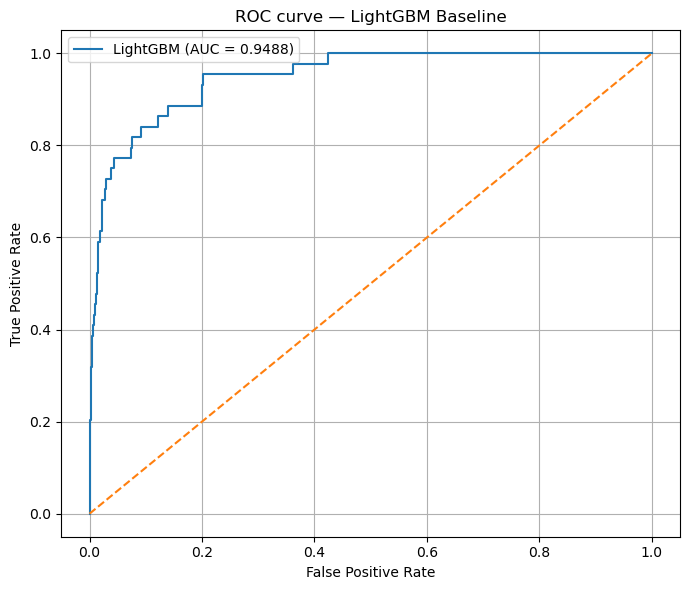

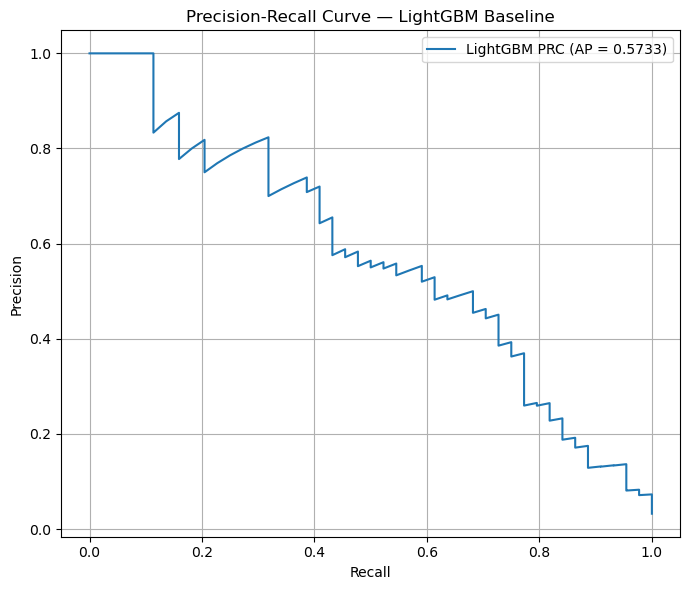

PRC AUC (Average Precision): 0.5733


<Figure size 640x480 with 0 Axes>

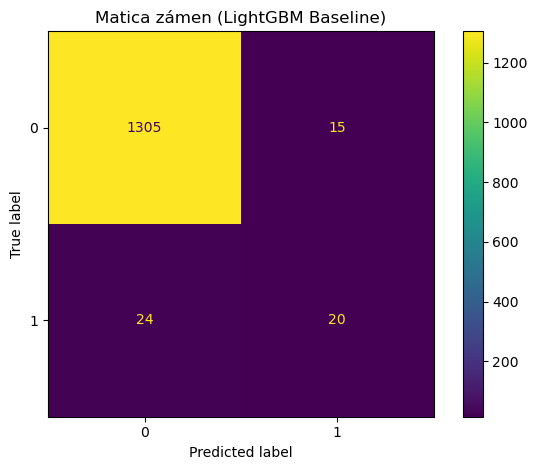

In [53]:
#Vytvorenie základného LightGBM modelu s váhou pre nevyvážené triedy
lgbm1 = LGBMClassifier(scale_pos_weight=scale_pos_weight_value)
lgbm1.fit(X_train, y_train)

y_pred1 = lgbm1.predict(X_test)
y_proba1 = lgbm1.predict_proba(X_test)[:, 1]

#Výpis metrík klasifikácie
print(classification_report(y_test, y_pred1, digits=5))

#ROC krivka
fpr_lgbm1, tpr_lgbm1, _ = roc_curve(y_test, y_proba1)
roc_auc_lgbm1 = auc(fpr_lgbm1, tpr_lgbm1)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lgbm1, tpr_lgbm1, label=f"LightGBM (AUC = {roc_auc_lgbm1:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — LightGBM Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Precision-Recall krivka
precisions_lgbm1, recalls_lgbm1, _ = precision_recall_curve(y_test, y_proba1)
prc_auc_lgbm1 = average_precision_score(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(recalls_lgbm1, precisions_lgbm1, label=f"LightGBM PRC (AP = {prc_auc_lgbm1:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — LightGBM Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc_lgbm1:.4f}")

#Matica zámen
cm_lgbm_baseline = confusion_matrix(y_test, y_pred1)
plt.figure()
ConfusionMatrixDisplay(cm_lgbm_baseline).plot()
plt.title("Matica zámen (LightGBM Baseline)")
plt.tight_layout()
plt.show()

### Baseline LightGBM + SMOTE ###

Classification Report (Baseline LightGBM + SMOTE)
              precision    recall  f1-score   support

           0    0.98407   0.98258   0.98332      1320
           1    0.50000   0.52273   0.51111        44

    accuracy                        0.96774      1364
   macro avg    0.74203   0.75265   0.74722      1364
weighted avg    0.96845   0.96774   0.96809      1364


Confusion Matrix
[[1297   23]
 [  21   23]]


<Figure size 600x500 with 0 Axes>

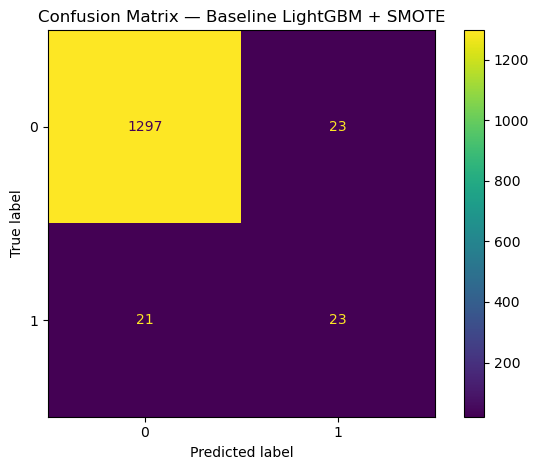

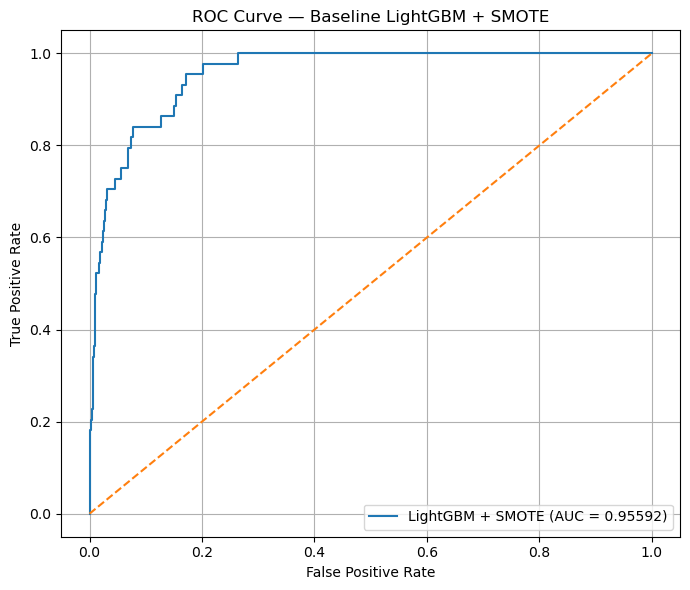

ROC AUC: 0.95592


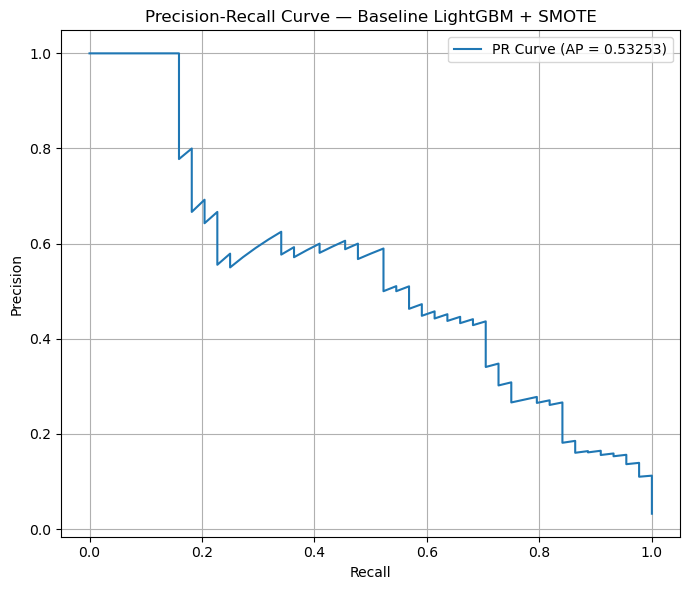

PRC AUC (Average Precision): 0.53253


In [35]:
#Vytvorenie pipeline so SMOTE a LightGBM modelom
baseline_smote_lgbm = ImbPipeline(steps=[
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            n_jobs=-1,
            verbose=-1
        )
    )
])

#Trénovanie pipeline na trénovacích dátach
baseline_smote_lgbm.fit(X_train, y_train)

#Trénovanie pipeline na trénovacích dátach
y_pred2 = baseline_smote_lgbm.predict(X_test)

#Predikcia tried na testovacích dátach
y_proba2 = baseline_smote_lgbm.predict_proba(X_test)[:, 1]


#Výpis metrík klasifikácie
print("Classification Report (Baseline LightGBM + SMOTE)")
print(classification_report(y_test, y_pred2, digits=5))

roc_auc2 = roc_auc_score(y_test, y_proba2)
prc_auc2 = average_precision_score(y_test, y_proba2)

#Matica zámen
cm = confusion_matrix(y_test, y_pred2)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline LightGBM + SMOTE")
plt.tight_layout()
plt.show()


#ROC krivka
fpr2, tpr2, _ = roc_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(fpr2, tpr2, label=f"LightGBM + SMOTE (AUC = {roc_auc2:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline LightGBM + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc2:.5f}")


#Precision-Recall krivka
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(recalls2, precisions2, label=f"PR Curve (AP = {prc_auc2:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline LightGBM + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc2:.5f}")

### Baseline LightGBM + ADASYN ###

Classification Report (Baseline LightGBM + ADASYN)
              precision    recall  f1-score   support

           0    0.98484   0.98409   0.98446      1320
           1    0.53333   0.54545   0.53933        44

    accuracy                        0.96994      1364
   macro avg    0.75909   0.76477   0.76189      1364
weighted avg    0.97027   0.96994   0.97010      1364


Confusion Matrix
[[1299   21]
 [  20   24]]


<Figure size 600x500 with 0 Axes>

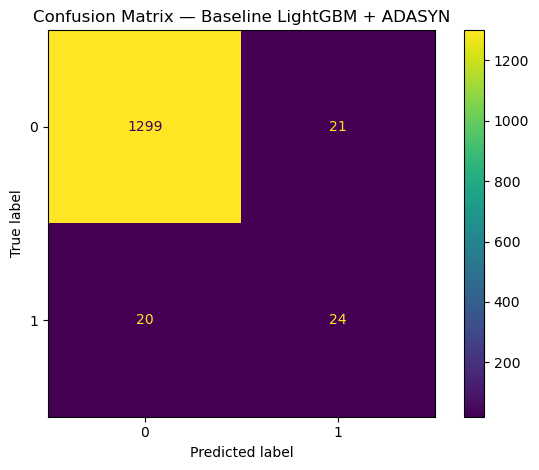

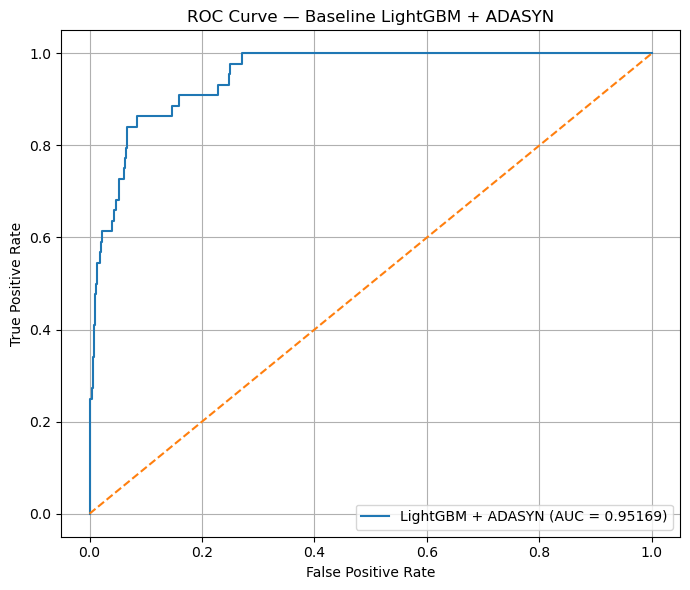

ROC AUC: 0.95169


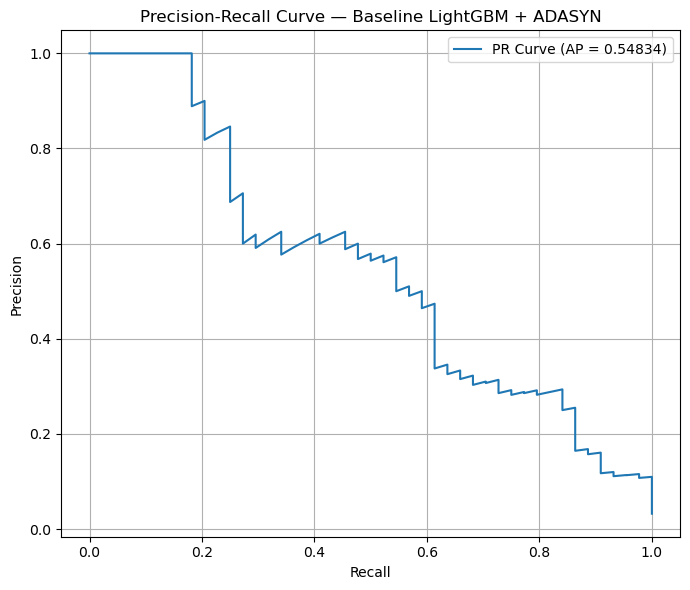

PRC AUC (Average Precision): 0.54834


In [39]:
#Vytvorenie pipeline s ADASYN a LightGBM modelom
baseline_adasyn_lgbm = ImbPipeline(steps=[
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=42,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=-1,
            n_jobs=-1,
            verbose=-1
        )
    )
])

#Trénovanie modelu na trénovacích dátach
baseline_adasyn_lgbm.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred3 = baseline_adasyn_lgbm.predict(X_test)

# Predikcia pravdepodobnosti pre triedu 1
y_proba3 = baseline_adasyn_lgbm.predict_proba(X_test)[:, 1]



#Výpis metrík klasifikácie
print("Classification Report (Baseline LightGBM + ADASYN)")
print(classification_report(y_test, y_pred3, digits=5))


roc_auc3 = roc_auc_score(y_test, y_proba3)
prc_auc3 = average_precision_score(y_test, y_proba3)

#Matica zámen
cm = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline LightGBM + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(fpr3, tpr3, label=f"LightGBM + ADASYN (AUC = {roc_auc3:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline LightGBM + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc3:.5f}")

#Precision-Recall krivka
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(recalls3, precisions3, label=f"PR Curve (AP = {prc_auc3:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline LightGBM + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc3:.5f}")

### LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 128 candidates, totalling 640 fits

Best params:
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__num_leaves': 15, 'model__scale_pos_weight': 2.0, 'smote__k_neighbors': 5, 'smote__sampling_strategy': 0.3, 'under__sampling_strategy': 0.05}
F1-score (CV): 0.4794

Threshold: 0.5679

Classification Report (LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9848    0.9811    0.9829      1320
           1     0.4898    0.5455    0.5161        44

    accuracy                         0.9670      1364
   macro avg     0.7373    0.7633    0.7495      1364
weighted avg     0.9688    0.9670    0.9679      1364


Confusion Matrix
[[1295   25]
 [  20   24]]


<Figure size 600x500 with 0 Axes>

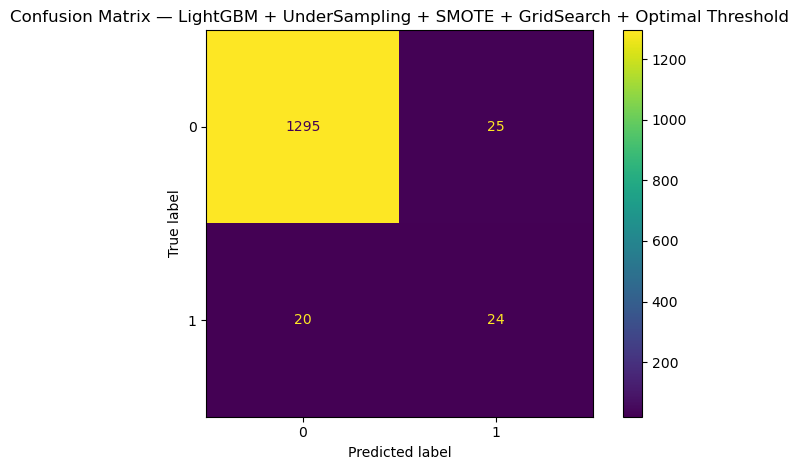

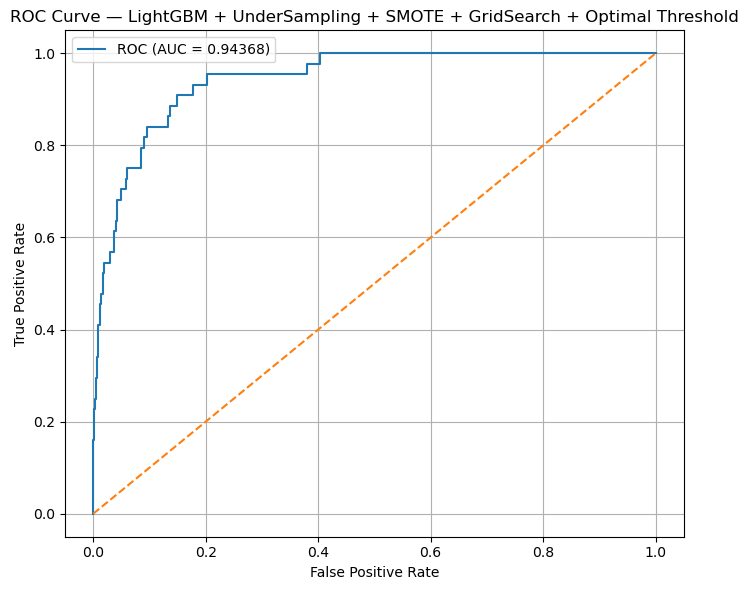

ROC AUC: 0.94368


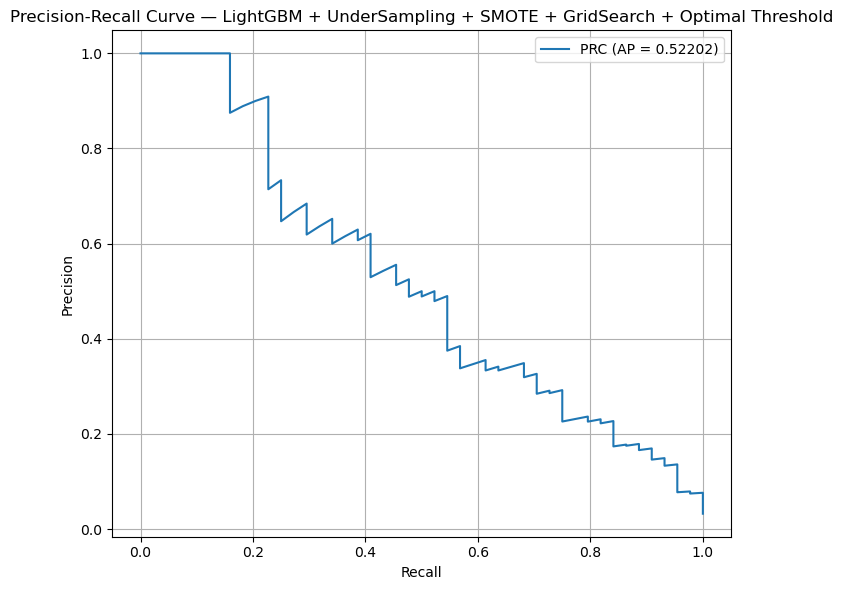

PRC AUC (Average Precision): 0.52202


In [45]:
#Vytvorenie pipeline s undersamplingom, SMOTE a LightGBM modelom
pipe = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8
        )
    )
])

#Definovanie rozsahu hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.05, 0.08],
    
    'smote__sampling_strategy': [0.25, 0.30],
    'smote__k_neighbors': [3, 5],
    
    'model__max_depth': [4, 5],
    'model__learning_rate': [0.03, 0.05],
    'model__scale_pos_weight': [1.5, 2.0],
    'model__num_leaves': [15, 31]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definovanie hodnotiacej metriky F1-score
scorer = make_scorer(f1_score, pos_label=1)

#Nastavenie GridSearchCV pre hľadanie najlepších parametrov
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

#Spustenie trénovania a hľadania najlepšieho modelu
grid_search.fit(X_train, y_train)

#Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

#Uloženie najlepšieho modelu
best_model1 = grid_search.best_estimator_

#Výpočet pravdepodobností pre triedu 1
probs = best_model1.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

#Výpočet F1-score pre rôzne prahy
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

#Výber prahu s najvyšším F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"\nThreshold: {best_threshold:.4f}")

#Predikcia tried podľa optimálneho prahu
y_pred_opt = (probs >= best_threshold).astype(int)

##Výpis metrík klasifikácie
print("\nClassification Report (LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred_opt, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred_opt)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.5f}")

# Precision-Recall krivka
prc_auc = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, label=f"PRC (AP = {prc_auc:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — LightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc:.5f}")

### LightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Best params:
{'adasyn__n_neighbors': 5, 'adasyn__sampling_strategy': 0.25, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__scale_pos_weight': 1.5, 'under__sampling_strategy': 0.05}
F1-score (CV): 0.4915

Threshold: 0.1260

Classification Report (LightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0     0.9892    0.9682    0.9786      1320
           1     0.4167    0.6818    0.5172        44

    accuracy                         0.9589      1364
   macro avg     0.7029    0.8250    0.7479      1364
weighted avg     0.9707    0.9589    0.9637      1364


Confusion Matrix
[[1278   42]
 [  14   30]]


<Figure size 600x500 with 0 Axes>

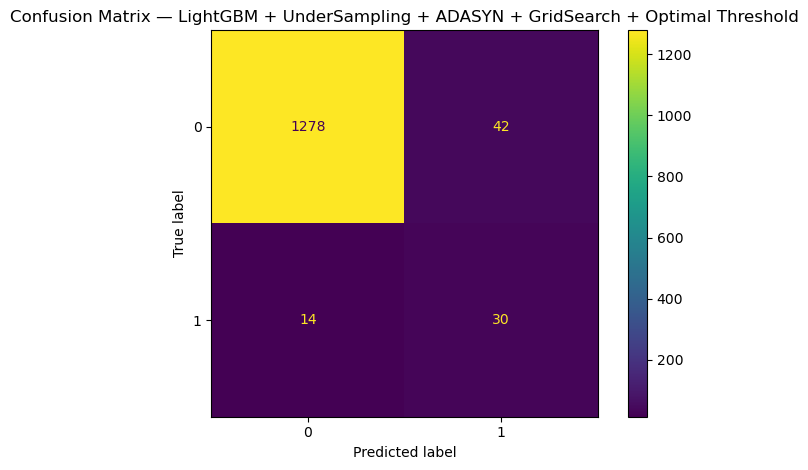

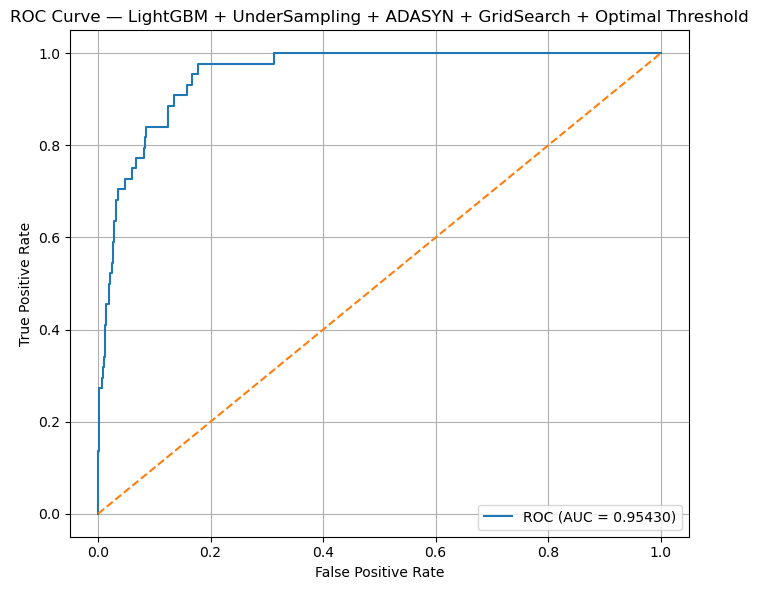

ROC AUC: 0.95430


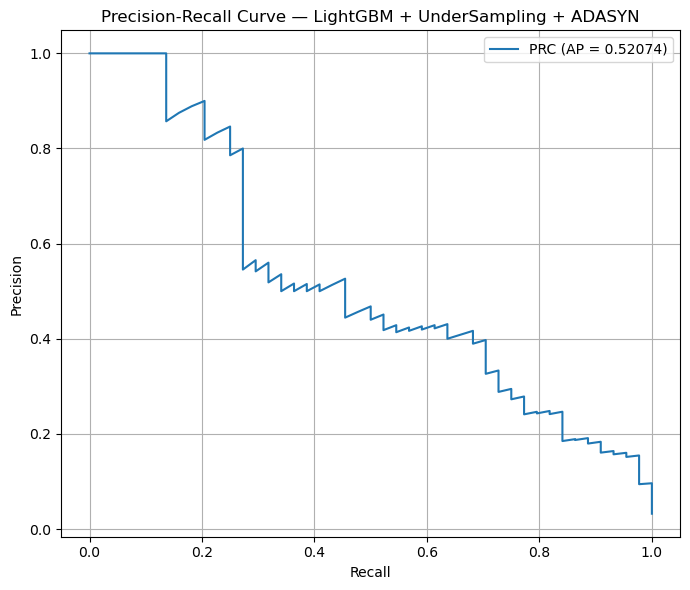

PRC AUC (Average Precision): 0.52074


In [58]:
#Vytvorenie pipeline s undersamplingom, ADASYN a LightGBM modelom
pipe = ImbPipeline(steps=[
    (
        "under",
        RandomUnderSampler(random_state=42)
    ),
    (
        "adasyn",
        ADASYN(random_state=42)
    ),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
            n_estimators=400,
            subsample=0.8,
            colsample_bytree=0.8
        )
    )
])

#Definovanie hyperparametrov pre GridSearch
param_grid = {
    'under__sampling_strategy': [0.05, 0.08],      

    'adasyn__sampling_strategy': [0.25, 0.30, 0.35],  
    'adasyn__n_neighbors': [3, 5],                    

    'model__max_depth': [4, 5, 6],                    
    'model__learning_rate': [0.03, 0.05],             
    'model__scale_pos_weight': [1.5, 2.0],            
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nastavenie F1-score ako hodnotiacej metriky
scorer = make_scorer(f1_score, pos_label=1)

# Vytvorenie GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

# Trénovanie modelu a hľadanie najlepších parametrov
grid_search.fit(X_train, y_train)

# Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)

# Výpis najlepšieho F1-score z krížovej validácie
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

# Uloženie najlepšieho modelu
best_model = grid_search.best_estimator_

# Výpočet pravdepodobností pre triedu 1
probs = best_model.predict_proba(X_test)[:, 1]

# Výpočet hodnôt pre Precision-Recall krivku
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

# Výpočet F1-score pre rôzne prahy
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)

# Výber najlepšieho prahu podľa F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nThreshold: {best_threshold:.4f}")

# Predikcia tried podľa optimálneho prahu
y_pred_opt2 = (probs >= best_threshold).astype(int)

#Výpis metrík klasifikácie
print("\nClassification Report (LightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred_opt2, digits=4))

#Matica zámen
cm = confusion_matrix(y_test, y_pred_opt2)
print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — LightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.5f}")


#Precision-Recall krivka
prc_auc = average_precision_score(y_test, probs)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, label=f"PRC (AP = {prc_auc:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — LightGBM + UnderSampling + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc:.5f}")

### Výsledky všetkých modelov ###

In [65]:
print("Baseline LightGBM")
print(classification_report(y_test, y_pred1))


print("\nBaseline LightGBM + SMOTE")
print(classification_report(y_test, y_pred2))


print("\nBaseline LightGBM + ADASYN")
print(classification_report(y_test, y_pred3))


print("\nLightGBM + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred_opt))


print("\nLightGBM + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred_opt2))

Baseline LightGBM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1320
           1       0.57      0.45      0.51        44

    accuracy                           0.97      1364
   macro avg       0.78      0.72      0.75      1364
weighted avg       0.97      0.97      0.97      1364


Baseline LightGBM + SMOTE
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.50      0.52      0.51        44

    accuracy                           0.97      1364
   macro avg       0.74      0.75      0.75      1364
weighted avg       0.97      0.97      0.97      1364


Baseline LightGBM + ADASYN
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.53      0.55      0.54        44

    accuracy                           0.97      1364
   macro avg       0.76      0.76      0.76      1364
w

### Permutation importance ###

                                              feature  importance
35                         Total debt/Total net worth    0.204545
9                Continuous interest rate (after tax)    0.136364
13                Interest-bearing debt interest rate    0.086364
33                                        Quick Ratio    0.054545
67                  Retained Earnings to Total Assets    0.045455
39                               Borrowing dependency    0.040909
18            Persistent EPS in the Last Four Seasons    0.022727
89                 Net Income to Stockholder's Equity    0.018182
0    ROA(C) before interest and depreciation befor...    0.013636
69                               Total expense/Assets    0.013636


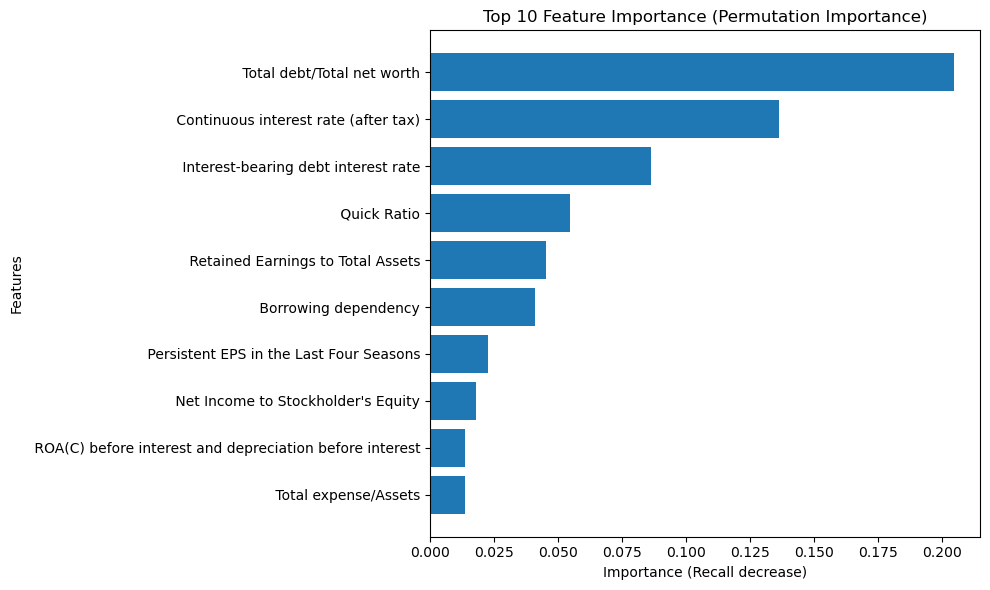

In [68]:
#Vytvorenie kópie testovacích dát
X_test_imp = X_test.copy()

#Výpočet permutation importance pre najlepší model
result = permutation_importance(
    best_model["model"],
    X_test_imp,
    y_test,
    scoring="recall",         
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

#Vytvorenie tabuľky s dôležitosťou premenných
importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

#Výpis 10 najdôležitejších premenných
print(importance_df.head(10))

#Výber 10 najdôležitejších premenných
top10 = importance_df.head(10)

#Vykreslenie grafu dôležitosti premenných
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Permutation Importance)")
plt.xlabel("Importance (Recall decrease)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

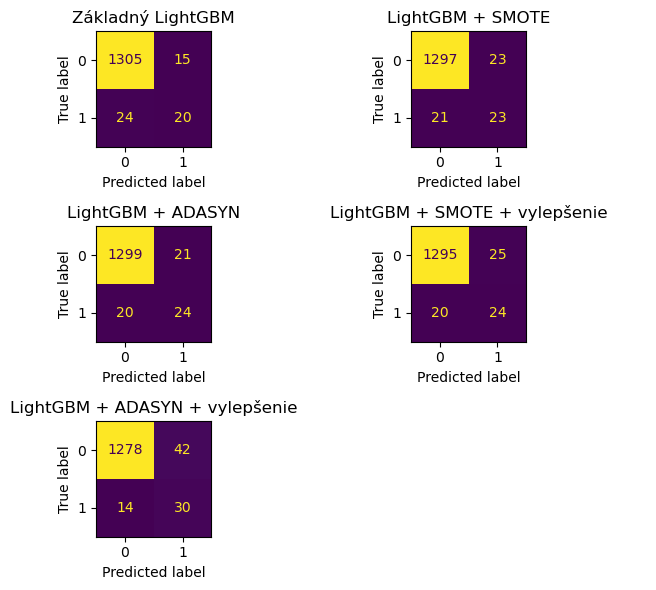

In [116]:
fig, axes = plt.subplots(3, 2, figsize=(7, 6))

cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Základný LightGBM")

cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("LightGBM + SMOTE")

cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("LightGBM + ADASYN")

cm4 = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm4).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("LightGBM + SMOTE + vylepšenie")

cm5 = confusion_matrix(y_test, y_pred_opt2)
ConfusionMatrixDisplay(cm5).plot(ax=axes[2, 0], colorbar=False)
axes[2, 0].set_title("LightGBM + ADASYN + vylepšenie")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

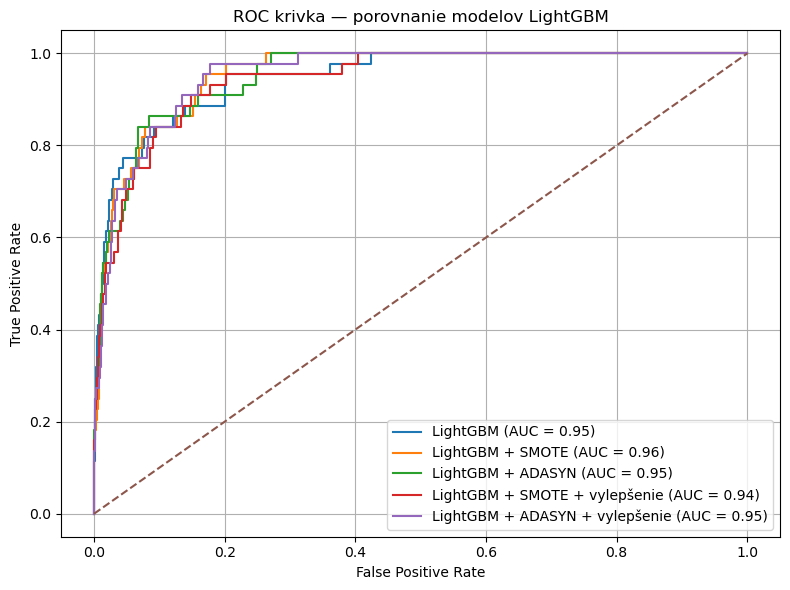

In [104]:
fpr1, tpr1, _ = roc_curve(y_test, y_proba1)
roc_auc1 = roc_auc_score(y_test, y_proba1)

fpr2, tpr2, _ = roc_curve(y_test, y_proba2)
roc_auc2 = roc_auc_score(y_test, y_proba2)

fpr3, tpr3, _ = roc_curve(y_test, y_proba3)
roc_auc3 = roc_auc_score(y_test, y_proba3)

y_proba4 = best_model1.predict_proba(X_test)[:, 1]
fpr4, tpr4, _ = roc_curve(y_test, y_proba4)
roc_auc4 = roc_auc_score(y_test, y_proba4)

y_proba5 = best_model.predict_proba(X_test)[:, 1]
fpr5, tpr5, _ = roc_curve(y_test, y_proba5)
roc_auc5 = roc_auc_score(y_test, y_proba5)

plt.figure(figsize=(8, 6))

plt.plot(fpr1, tpr1, label=f"LightGBM (AUC = {roc_auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"LightGBM + SMOTE (AUC = {roc_auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"LightGBM + ADASYN (AUC = {roc_auc3:.2f})")
plt.plot(fpr4, tpr4, label=f"LightGBM + SMOTE + vylepšenie (AUC = {roc_auc4:.2f})")
plt.plot(fpr5, tpr5, label=f"LightGBM + ADASYN + vylepšenie (AUC = {roc_auc5:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka — porovnanie modelov LightGBM")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

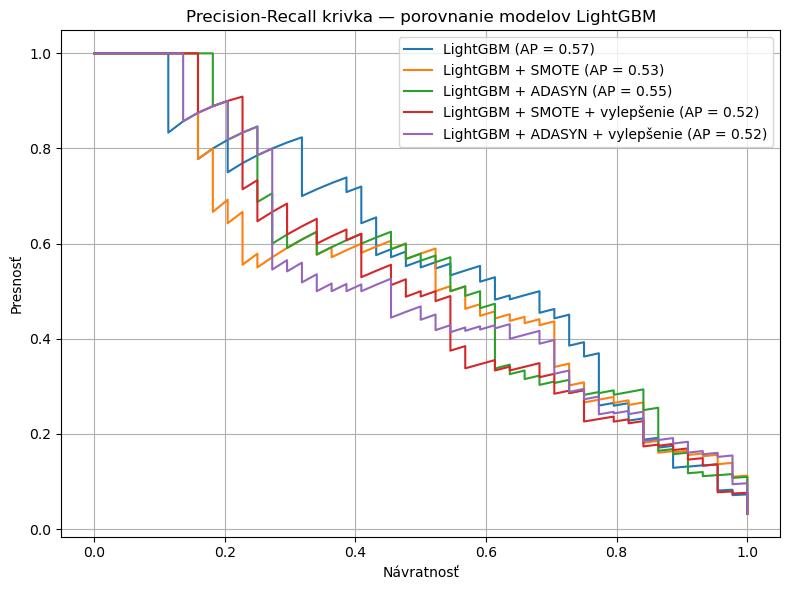

In [108]:
prec1, rec1, _ = precision_recall_curve(y_test, y_proba1)
ap1 = average_precision_score(y_test, y_proba1)

prec2, rec2, _ = precision_recall_curve(y_test, y_proba2)
ap2 = average_precision_score(y_test, y_proba2)

prec3, rec3, _ = precision_recall_curve(y_test, y_proba3)
ap3 = average_precision_score(y_test, y_proba3)

y_proba4 = best_model1.predict_proba(X_test)[:, 1]
prec4, rec4, _ = precision_recall_curve(y_test, y_proba4)
ap4 = average_precision_score(y_test, y_proba4)

y_proba5 = best_model.predict_proba(X_test)[:, 1]
prec5, rec5, _ = precision_recall_curve(y_test, y_proba5)
ap5 = average_precision_score(y_test, y_proba5)

plt.figure(figsize=(8, 6))

plt.plot(rec1, prec1, label=f"LightGBM (AP = {ap1:.2f})")
plt.plot(rec2, prec2, label=f"LightGBM + SMOTE (AP = {ap2:.2f})")
plt.plot(rec3, prec3, label=f"LightGBM + ADASYN (AP = {ap3:.2f})")
plt.plot(rec4, prec4, label=f"LightGBM + SMOTE + vylepšenie (AP = {ap4:.2f})")
plt.plot(rec5, prec5, label=f"LightGBM + ADASYN + vylepšenie (AP = {ap5:.2f})")

plt.xlabel("Návratnosť")
plt.ylabel("Presnosť")
plt.title("Precision-Recall krivka — porovnanie modelov LightGBM")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()